In [1]:
import pandas as pd
import numpy as np
import os
from typing import Iterator, Union, List, Optional
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import date



In [2]:
# Read the csvs and excels
cols = pd.read_csv("../columns.csv")["Column Names"].tolist()
database = pd.read_parquet("../planning_data/database/database_cleaned_p2.parquet")
Xovis_info = pd.ExcelFile("../../planning/xovis.xlsx")

In [3]:
database

,From,To Time,Z08_HEC1M-ELEV18_IN,Z08_HEC1M-ELEV18_OUT,Z33_C1-WestConcourse_IN,Z33_C1-WestConcourse_OUT,Z32_T1ESC19&20/ZONE32_NorthEsc_IN,Z32_T1ESC19&20/ZONE32_NorthEsc_OUT,Z32_T1ESC19&20/ZONE32_SouththEsc_IN,Z32_T1ESC19&20/ZONE32_SouththEsc_OUT,...,Z19_PATHturnstiles-East_249-255(south)_IN,Z19_PATHturnstiles-East_249-255(south)_OUT,Z19_PATHturnstiles-East_256-261(center)_IN,Z19_PATHturnstiles-East_256-261(center)_OUT,Z19_PATHturnstiles-East_262-267(center)_IN,Z19_PATHturnstiles-East_262-267(center)_OUT,Z19_PATHturnstiles-East_268-274(north)_IN,Z19_PATHturnstiles-East_268-274(north)_OUT,Z20_PATHturnstiles-SE_Passageway-North_NB,Z20_PATHturnstiles-SE_Passageway-North_SB
0,2023-10-01 00:00:00,2023-10-01 00:05:00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,17.0,1.0,13.0,1.0,9.0,0.0,7.0,3.0,0.0
1,2023-10-01 00:05:00,2023-10-01 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,14.0,0.0,9.0,1.0,12.0,0.0,18.0,5.0,3.0
2,2023-10-01 00:10:00,2023-10-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,18.0,0.0,1.0,5.0,16.0,2.0,3.0
3,2023-10-01 00:15:00,2023-10-01 00:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,26.0,18.0,47.0,21.0,19.0,12.0,3.0,23.0,5.0,0.0
4,2023-10-01 00:20:00,2023-10-01 00:25:00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,3.0,17.0,1.0,8.0,0.0,11.0,1.0,14.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131899,2024-12-31 23:35:00,2024-12-31 23:40:00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,2.0,16.0,0.0,8.0,0.0,3.0,0.0,8.0,6.0,1.0
131900,2024-12-31 23:40:00,2024-12-31 23:45:00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.0,23.0,2.0,16.0,1.0,11.0,7.0,3.0,7.0,0.0
131901,2024-12-31 23:45:00,2024-12-31 23:50:00,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,...,21.0,15.0,5.0,9.0,7.0,16.0,17.0,5.0,3.0,2.0
131902,2024-12-31 23:50:00,2024-12-31 23:55:00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,10.0,0.0,10.0,0.0,2.0,0.0,0.0,3.0,0.0


In [36]:
# Read in current database, then save and timestamp old database + archive

parquet_filename_p1 = f"../planning_data/database/database_cleaned_p1.parquet"
parquet_filename_p2 = f"../planning_data/database/database_cleaned_p2.parquet"

cols = pd.read_csv("../columns.csv")["Column Names"].tolist()
cols_p2 = pd.read_csv("../p2_columns.csv")["Column Names"].tolist()
df_database_p1 = pd.read_parquet(parquet_filename_p1,columns= cols, engine="pyarrow")
df_database_p2 = pd.read_parquet(parquet_filename_p2,columns= cols_p2, engine="pyarrow")


different_cols = df_database_p2.columns.difference(df_database_p1.columns)

# Get the first two entries from cols
required_cols = cols[:2]  # ['From', 'To']

# Convert Index to list and prepend the required columns
combined_cols = required_cols + different_cols.tolist()
combined_cols
# Use these columns to create the combined dataframe
combined_p2_df = df_database_p2[combined_cols]


# different_cols.size
# Make sure 'From' and 'To' are in both DataFrames (they already are)
# Merge on them explicitly
combined_df = pd.merge(
    df_database_p1,
    combined_p2_df,
    how='left',
    on=['From', 'To Time']
)


combined_df


,From,To Time,Z01_T4-ChurchSt_RevDoor_IN,Z01_T4-ChurchSt_RevDoor_OUT,Z01_T4-ChurchSt_SwingDoor_IN,Z01_T4-ChurchSt_SwingDoor_OUT,Z02_T4-LibertySt_EastEsc46_IN,Z02_T4-LibertySt_EastEsc46_OUT,Z02_T4-LibertySt_WestEsc45_IN,Z02_T4-LibertySt_WestEsc45_OUT,...,Z41_SouthWestPassage(South)_IN,Z41_SouthWestPassage(South)_OUT,Z42_CenterPassage_IN,Z42_CenterPassage_OUT,Z42_CenterPassage_Stair_IN,Z42_CenterPassage_Stair_OUT,Z43_NorthWestPassage_IN,Z43_NorthWestPassage_OUT,Z43_SouthWestPassage_IN,Z43_SouthWestPassage_OUT
0,2020-02-24 00:00:00,2020-02-24 00:05:00,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-02-24 00:05:00,2020-02-24 00:10:00,0.0,0.0,3.0,0.0,0.0,1.0,4.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-02-24 00:10:00,2020-02-24 00:15:00,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-02-24 00:15:00,2020-02-24 00:20:00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-02-24 00:20:00,2020-02-24 00:25:00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545179,2025-04-30 23:35:00,2025-04-30 23:40:00,0.0,0.0,0.0,0.0,3.0,0.0,0.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
545180,2025-04-30 23:40:00,2025-04-30 23:45:00,0.0,0.0,0.0,0.0,3.0,0.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
545181,2025-04-30 23:45:00,2025-04-30 23:50:00,0.0,0.0,0.0,2.0,8.0,0.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
545182,2025-04-30 23:50:00,2025-04-30 23:55:00,0.0,0.0,0.0,1.0,3.0,0.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


['From',
 'To Time',
 'Z06_C1-WestProjection_Elevator_IN',
 'Z06_C1-WestProjection_Elevator_OUT',
 'Z08_EastProj-C1-StairEsc_Elev_INTOFELEV',
 'Z08_HEC1M-ELEV18_IN',
 'Z08_HEC1M-ELEV18_OUT',
 'Z14_T1-Observatory-Entry_Elev_INTOFELEV',
 'Z32_T1ESC19&20/ZONE32_NorthEsc_IN',
 'Z32_T1ESC19&20/ZONE32_NorthEsc_OUT',
 'Z32_T1ESC19&20/ZONE32_SouththEsc_IN',
 'Z32_T1ESC19&20/ZONE32_SouththEsc_OUT',
 'Z33_C1-WestConcourse_IN',
 'Z33_C1-WestConcourse_OUT',
 'Z34_South Blacony Ring_West_Esc_IN',
 'Z34_South Blacony Ring_West_Esc_OUT',
 'Z34_South Blacony Ring_West_Stair_IN',
 'Z34_South Blacony Ring_West_Stair_OUT',
 'Z34_SouthBalconyRing_EastEsc_IN',
 'Z34_SouthBalconyRing_EastEsc_OUT',
 'Z34_SouthBalconyRing_EastStair_IN',
 'Z34_SouthBalconyRing_EastStair_OUT',
 'Z34_SouthBalconyRing_Passage_IN',
 'Z34_SouthBalconyRing_Passage_OUT',
 'Z35_NorthBalconyRing_Passage_IN',
 'Z35_NorthBalconyRing_Passage_IN.1',
 'Z35_NorthBalconyRing_Passage_OUT',
 'Z35_NorthBalconyRing_Passage_OUT.1',
 'Z35_NorthBalc

In [31]:
cols[1:2]

['To Time']

In [23]:
long_df

,Month,Year,variable,Count
0,10,2023,Z08_HEC1M-ELEV18_IN,0.0
1,10,2023,Z08_HEC1M-ELEV18_IN,0.0
2,10,2023,Z08_HEC1M-ELEV18_IN,0.0
3,10,2023,Z08_HEC1M-ELEV18_IN,0.0
4,10,2023,Z08_HEC1M-ELEV18_IN,0.0
...,...,...,...,...
17938939,12,2024,Z20_PATHturnstiles-SE_Passageway-North_SB,1.0
17938940,12,2024,Z20_PATHturnstiles-SE_Passageway-North_SB,0.0
17938941,12,2024,Z20_PATHturnstiles-SE_Passageway-North_SB,2.0
17938942,12,2024,Z20_PATHturnstiles-SE_Passageway-North_SB,0.0


In [150]:
Xovis_SS = Xovis[Xovis["From"].notnull()]\
    .drop_duplicates(subset=['From'])
turnstiles = Xovis_SS.columns[2:186].to_list()
cols_tosave = Xovis_SS.columns[0:186].to_list()
Xovis_SS[turnstiles] = Xovis_SS[turnstiles].apply(pd.to_numeric, errors='coerce')
Xovis_SS = Xovis_SS[cols_tosave]
# # Keep the first two columns
first_two_cols = Xovis_SS.iloc[:, :2]
# # Filter rows where all other columns have values smaller than 500
filtered_data = ~(Xovis_SS.iloc[:, 2:] >= 500).any(axis=1)
# # Combine the first two columns with the filtered data
Xovis_SS = Xovis_SS.loc[filtered_data]
# Xovis_SS.to_parquet("../planning_data/database/Xovis_SS_5min.parquet")
print(len(Xovis_SS))
print(Xovis_SS.iloc[:, 2:].max().max())
Xovis_SS

369690
498.0


,From,To Time,Z01_T4-ChurchSt_RevDoor_IN,Z01_T4-ChurchSt_RevDoor_OUT,Z01_T4-ChurchSt_SwingDoor_IN,Z01_T4-ChurchSt_SwingDoor_OUT,Z02_T4-LibertySt_EastEsc46_IN,Z02_T4-LibertySt_EastEsc46_OUT,Z02_T4-LibertySt_WestEsc45_IN,Z02_T4-LibertySt_WestEsc45_OUT,...,Z27_T3TransitLobby_Stair50_DOWN_IN,Z27_T3TransitLobby_Stair50_UP_OUT,Z28_T3Elev-C1_OUTOFELEV_IN,Z28_T3Elev-C1_INTOELEV_OUT,Z28_1Train-C1-SConc_AllDoors_IN,Z28_1Train-C1-SConc_AllDoors_OUT,Z31_T3Elev-C2_OUTOFELEV_IN,Z31_T3Elev-C2_INTOELEV_OUT,Z29_C2_SWOculus_HubElev_OUTOFELEV,Z29_C2_SWOculus_HubElev_INTOELEV
0,2021-06-27 00:00:00,2021-06-27 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2021-06-27 00:05:00,2021-06-27 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2021-06-27 00:10:00,2021-06-27 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2021-06-27 00:15:00,2021-06-27 00:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,3.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4,2021-06-27 00:20:00,2021-06-27 00:25:00,0.0,0.0,0.0,2.0,0.0,1.0,1.0,3.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388933,2024-12-31 23:35:00,2024-12-31 23:40:00,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,3.0,4.0,0.0,0.0,0.0,0.0
388934,2024-12-31 23:40:00,2024-12-31 23:45:00,1.0,0.0,1.0,2.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
388935,2024-12-31 23:45:00,2024-12-31 23:50:00,0.0,0.0,1.0,2.0,2.0,0.0,0.0,5.0,...,0.0,0.0,3.0,0.0,0.0,4.0,1.0,3.0,0.0,0.0
388936,2024-12-31 23:50:00,2024-12-31 23:55:00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [151]:
# Group by date and sum all numeric columns, excluding time-related columns
daily_aggregation = Xovis_SS.groupby(Xovis_SS['From'].dt.date).agg(
    lambda x: x.sum() if pd.api.types.is_numeric_dtype(x) else x.iloc[0]
)
# First, identify and drop 'From' and 'To Time' columns
daily_aggregation_combined = daily_aggregation.drop(columns=['From', 'To Time'])\
                            .reset_index()
daily_aggregation_combined_turnstiles = daily_aggregation_combined
daily_aggregation_combined_turnstiles['Total Count'] = daily_aggregation_combined_turnstiles.sum(axis = 1, numeric_only = True)
daily_aggregation_combined_compare = daily_aggregation_combined_turnstiles.drop(daily_aggregation_combined.columns[1:185].to_list(),axis= 1)
daily_aggregation_combined_compare

,From,Total Count
0,2021-06-27,193531.0
1,2021-06-28,244571.0
2,2021-06-29,247244.0
3,2021-06-30,245641.0
4,2021-07-01,262384.0
...,...,...
1279,2024-12-27,579028.0
1280,2024-12-28,473272.0
1281,2024-12-29,423871.0
1282,2024-12-30,585052.0


In [152]:
parquet_files = [f for f in os.listdir('../planning_data/ped_report_parquet/archive') if f.endswith('.parquet')]
# parquet_files
dfs = []
for file in parquet_files:
    file_path = os.path.join('../planning_data/ped_report_parquet/archive', file)
    # arch_path = os.path.join('../planning_data/ped_report_parquet/archive', file)
    try:
        df = pd.read_parquet(file_path, engine="pyarrow")
        dfs.append(df) 
    except Exception as e:
        print(f"Error reading {file}: {e}")
else:
    print("No valid data to save.")
if dfs:
    # Concatenate all DataFrames into one
    combined_df = pd.concat(dfs, ignore_index=True)
else:
    print("No Parquet files to process.")

df = combined_df.drop_duplicates().reset_index(drop=True)
# Keep the first two columns
first_two_cols = df.iloc[:, :2]
# Filter rows where all other columns have values smaller than 500
filtered_data = df.iloc[:, 2:].lt(500).all(axis=1)
# Combine the first two columns with the filtered data
df = df.loc[filtered_data]
df
daily_aggregation_pa = df.groupby(df['From'].dt.date).agg(
    lambda x: x.sum() if pd.api.types.is_numeric_dtype(x) else x.iloc[0]
)
daily_aggregation_combined_pa = daily_aggregation_pa.drop(columns=['From', 'To Time'])

No valid data to save.


In [153]:
daily_aggregation_combined_pa = daily_aggregation_pa\
        .drop(columns=['From', 'To Time'])\
        .reset_index()
daily_aggregation_combined_pa['Total Count'] = daily_aggregation_combined_pa[turnstiles].sum(axis=1)
daily_aggregation_combined_pa_compare = daily_aggregation_combined_pa.drop(turnstiles,axis= 1)
daily_aggregation_combined_pa_compare

,From,Total Count
0,2020-02-24,671968.0
1,2020-02-25,722856.0
2,2020-02-26,706988.0
3,2020-02-27,745150.0
4,2020-02-28,738723.0
...,...,...
1576,2024-08-27,514696.0
1577,2024-08-28,521131.0
1578,2024-08-29,488313.0
1579,2024-08-30,424393.0


In [154]:
comparing = daily_aggregation_combined_compare.merge(daily_aggregation_combined_pa_compare,how = "left",on="From")
comparing['difference'] = comparing['Total Count_y'] - comparing['Total Count_x']
comparing['perc'] = round(comparing['difference']/comparing['Total Count_x']*100,2)
comparing.replace([np.inf, -np.inf], np.nan, inplace=True) 
comparing

,From,Total Count_x,Total Count_y,difference,perc
0,2021-06-27,193531.0,193317.0,-214.0,-0.11
1,2021-06-28,244571.0,244316.0,-255.0,-0.10
2,2021-06-29,247244.0,247022.0,-222.0,-0.09
3,2021-06-30,245641.0,245392.0,-249.0,-0.10
4,2021-07-01,262384.0,262086.0,-298.0,-0.11
...,...,...,...,...,...
1279,2024-12-27,579028.0,NaN,NaN,NaN
1280,2024-12-28,473272.0,NaN,NaN,NaN
1281,2024-12-29,423871.0,NaN,NaN,NaN
1282,2024-12-30,585052.0,NaN,NaN,NaN


In [155]:
print("min: ", comparing['perc'].min())
print("max: ", comparing['perc'].max())
print("median: ", comparing['perc'].median())
print("mode: ", comparing['perc'].mode())
print("mean: ", comparing['perc'].mean())
comparing['From'] = pd.to_datetime(comparing['From'])
comparing#.dtypes


min:  -91.82
max:  2334.13
median:  -0.09
mode:  0   -0.08
Name: perc, dtype: float64
mean:  2.450963302752293


,From,Total Count_x,Total Count_y,difference,perc
0,2021-06-27,193531.0,193317.0,-214.0,-0.11
1,2021-06-28,244571.0,244316.0,-255.0,-0.10
2,2021-06-29,247244.0,247022.0,-222.0,-0.09
3,2021-06-30,245641.0,245392.0,-249.0,-0.10
4,2021-07-01,262384.0,262086.0,-298.0,-0.11
...,...,...,...,...,...
1279,2024-12-27,579028.0,NaN,NaN,NaN
1280,2024-12-28,473272.0,NaN,NaN,NaN
1281,2024-12-29,423871.0,NaN,NaN,NaN
1282,2024-12-30,585052.0,NaN,NaN,NaN


In [156]:
comparing_outliers = comparing#[comparing["perc"]>3]
comparing_outliers = comparing_outliers.sort_values(by ='Total Count_x',ascending = False)
comparing_outliers

,From,Total Count_x,Total Count_y,difference,perc
1011,2024-04-03,661253.0,660931.0,-322.0,-0.05
1172,2024-09-11,653484.0,NaN,NaN,NaN
1264,2024-12-12,624466.0,NaN,NaN,NaN
1004,2024-03-27,617429.0,617043.0,-386.0,-0.06
1012,2024-04-04,611247.0,610773.0,-474.0,-0.08
...,...,...,...,...,...
609,2023-02-26,0.0,211842.0,211842.0,NaN
610,2023-02-27,0.0,381594.0,381594.0,NaN
611,2023-02-28,0.0,390614.0,390614.0,NaN
612,2023-03-01,0.0,477816.0,477816.0,NaN


In [157]:
# Xovis_info.sheet_names
def compare_datasets(dataset):
    Xovis_ss = pd.read_excel("../../planning/xovis.xlsx", sheet_name= dataset)
    Xovis_ss = Xovis_ss.dropna()
    Xovis_ss[turnstiles] = Xovis_ss[turnstiles].apply(pd.to_numeric, errors='coerce')
    Xovis_ss['Total Count'] = Xovis_ss[turnstiles].sum(axis=1)
    Xovis_ss = Xovis_ss.drop(turnstiles, axis = 1)
    Xovis_ss = Xovis_ss.drop(["To Time"],axis = 1)

    global daily_aggregation_combined_pa_compare
    daily_aggregation_combined_pa_funct = daily_aggregation_combined_pa_compare.reset_index()
    daily_aggregation_combined_pa_funct["From"] = pd.to_datetime(daily_aggregation_combined_pa_funct["From"])
    comparing_ss = Xovis_ss.merge(daily_aggregation_combined_pa_funct,how = "left",on="From")
    # comparing_ss = comparing_ss.dropna()
    
    comparing_ss['difference'] = comparing_ss['Total Count_y'] - comparing_ss['Total Count_x']
    comparing_ss['perc'] = round(comparing_ss['difference']/comparing_ss['Total Count_x']*100,2)
    # print(max(comparing['difference']))
    comparing_ss.replace([np.inf, -np.inf], np.nan, inplace=True) 
    # comparing_ss.dropna(inplace=True)
    comparing_ss = comparing_ss.drop('index', axis=1)

    return(comparing_ss)

C:\Users\schew\AppData\Local\Temp\ipykernel_6324\1495349284.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Xovis_ss['Total Count'] = Xovis_ss[turnstiles].sum(axis=1)
C:\Users\schew\AppData\Local\Temp\ipykernel_6324\1495349284.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Xovis_ss['Total Count'] = Xovis_ss[turnstiles].sum(axis=1)


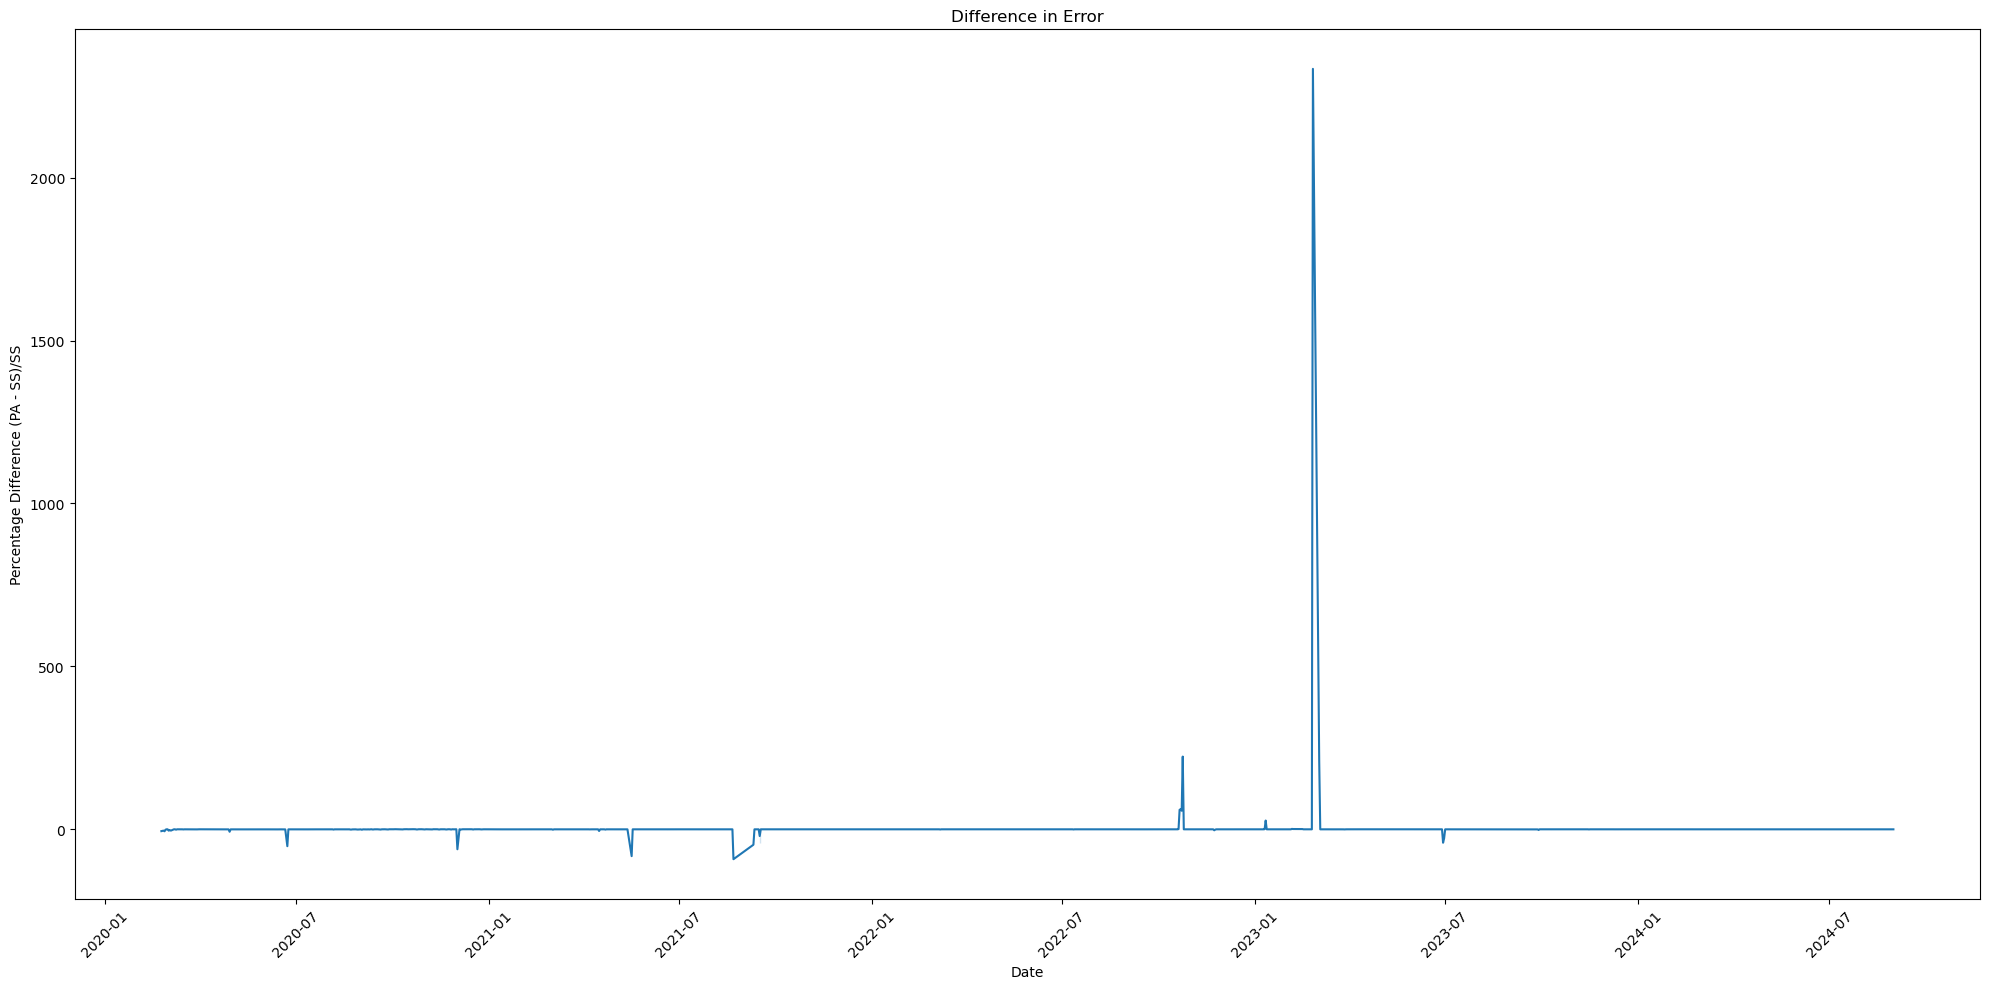

In [158]:
daily2020 = compare_datasets('XOVIS 2020 (Daily)')
daily2021 = compare_datasets('XOVIS 2021 (Daily)')
all_df = [daily2020,daily2021,comparing]
all_dailys = pd.concat(all_df, ignore_index = True)\
    .drop_duplicates() \
    .sort_values(by = "From") \
    .reset_index(drop = True)
all_dailys

plt.figure(figsize=(20, 10))

# Create the bar plot, but order by date
all_dailys = all_dailys.sort_values('From')
sns.lineplot(data=all_dailys, x='From', y='perc')

# Format x-axis to show months and years
ax = plt.gca()

# Add title and labels
plt.title('Difference in Error')
plt.xlabel('Date')
plt.ylabel('Percentage Difference (PA - SS)/SS')

# Rotate labels
plt.xticks(rotation=45)
ax.ticklabel_format(style='plain', axis='y')
plt.tight_layout()

plt.show()

In [159]:
all_dailys.to_csv("../planning_data/QAQC/all_dailys.csv")

In [160]:
# For the huge outage:
xovis = Xovis_SS
xovis["From"] = pd.to_datetime(xovis["From"])
# xovis
PA = df
PA["From"] = pd.to_datetime(PA["From"])

PA_test = PA[PA["From"].dt.date == pd.to_datetime("2023-02-25").date()]
xovis_test = xovis[xovis["From"].dt.date == pd.to_datetime("2023-02-25").date()]
PA_test.to_csv("../planning_data/QAQC/feb2023_test_PA.csv")
xovis_test.to_csv("../planning_data/QAQC/feb2023_test_xovis.csv")
# concat = [xovis_test,PA_test]
# march_test = pd.concat(concat, ignore_index=True)

# march_test
#xovis_test


In [161]:
PA_extreme = PA[PA["From"].dt.date == pd.to_datetime("2024-05-05").date()]
xovis_extreme = xovis[xovis["From"].dt.date == pd.to_datetime("2024-05-05").date()]
PA_extreme.to_csv("../planning_data/QAQC/may24_test_PA.csv")
xovis_extreme.to_csv("../planning_data/QAQC/may24_test_xovis.csv")
# concat = [xovis_test,PA_test]
# march_test = pd.concat(concat, ignore_index=True)

# march_test
#xovis_test


In [162]:
PA_extreme = PA[PA["From"].dt.date == pd.to_datetime("2024-07-22").date()]
xovis_extreme = xovis[xovis["From"].dt.date == pd.to_datetime("2024-07-22").date()]
PA_extreme.to_csv("../planning_data/QAQC/july2024_test_PA.csv")
xovis_extreme.to_csv("../planning_data/QAQC/july2024_xovis.csv")
# concat = [xovis_test,PA_test]
# march_test = pd.concat(concat, ignore_index=True)

# march_test
#xovis_test

In [163]:
def calculate_df_differences(datetext):
    # Filter data for the specific date and reset indices,
    PA_extreme = PA[PA["From"].dt.date == pd.to_datetime(datetext).date()].reset_index(drop=True)
    xovis_extreme = xovis[xovis["From"].dt.date == pd.to_datetime(datetext).date()].reset_index(drop=True)

    # Calculate differences
    diff_df = PA_extreme.iloc[0:len(PA_extreme), :] - xovis_extreme.iloc[0:len(PA_extreme), :]

    # Keep the datetime columns from the original dataframe
    diff_df['From'] = PA_extreme['From']
    diff_df['To Time'] = PA_extreme['To Time']

    # Identify numeric columns (sensor data)
    numeric_cols = diff_df.select_dtypes(include=['float64', 'int64']).columns
    # Filter out rows where all numeric columns are 0
    rows_with_diff = (diff_df[numeric_cols] != 0).any(axis=1)
    diff_df_filtered = diff_df[rows_with_diff]

    # Compute summary statistics
    summary_df = pd.DataFrame({
        'Max_Difference': diff_df[numeric_cols].abs().max().round(0),  # Absolute max
        'Count_of_Discrepancies': (diff_df[numeric_cols] != 0).sum().round(0),
        'Total_Difference': diff_df[numeric_cols].sum(),
        'Average_Difference': diff_df[numeric_cols].mean().round(0)
    }) \
        .query("abs(Total_Difference) > 100") \
        .sort_values('Total_Difference', ascending=False)

    # Get the sensors (columns) where Max_Difference occurs
    sensors_with_issues = summary_df.index.tolist()  # Sensor names with discrepancies

    # Find timestamps where Max_Difference occurs for each sensor
    timestamps_with_max_diff = set()
    for sensor in sensors_with_issues:
        max_value = summary_df.loc[sensor, 'Max_Difference']
        matching_rows = diff_df_filtered[diff_df_filtered[sensor].abs() == max_value]  # Match absolute values
        timestamps_with_max_diff.update(matching_rows['From'])

    # Ensure timestamps are found before filtering
    if timestamps_with_max_diff:
        final_filtered_df = diff_df_filtered[diff_df_filtered['From'].isin(timestamps_with_max_diff)][['From', 'To Time'] + sensors_with_issues]
    else:
        final_filtered_df = pd.DataFrame(columns=['From', 'To Time'] + sensors_with_issues)  # Return empty df with proper columns
    return final_filtered_df, summary_df
# Test the function
differences, summary = calculate_df_differences("2024-05-05")
differences, summary = calculate_df_differences("2024-07-11")
differences, summary = calculate_df_differences("2024-07-22")
differences, summary = calculate_df_differences("2024-06-15")
differences, summary = calculate_df_differences("2024-05-17")

differences  # This should return only rows where Max_Difference occurs for sensors in summary_df"



,From,To Time,Z29_C2_SWOculus_HubElev_INTOELEV
220,2024-05-17 18:20:00,2024-05-17 18:25:00,-11.0


In [164]:
# List of dates extracted from the image
date_list = [
    "3/3/2023", "5/31/2023", "6/29/2023", "6/30/2023", "8/25/2023",
    "10/3/2023", "10/5/2023", "11/15/2023", "11/24/2023", "12/9/2023",
    "4/10/2024", "4/12/2024", "5/5/2024", "6/15/2024", "6/27/2024",
    "7/11/2024", "7/22/2024", "7/30/2024", "7/31/2024", "8/2/2024", "8/29/2024",
    "2/24/2020", "2/27/2020", "4/29/2020", "6/22/2020", "6/23/2020",
    "12/2/2020", "12/3/2020", "4/16/2021", "5/17/2021", "8/22/2021",
    "9/10/2021", "9/16/2021", "4/8/2022", "10/21/2022", "10/22/2022",
    "10/23/2022", "10/24/2022", "1/11/2023"
]

# Dictionary to store results for each date
results = {}

for date in date_list:
    differences, summary = calculate_df_differences(date)
    results[date] = {
        "differences": differences,
        "summary": summary
    }
    print(f"Processed {date}")

# Check results for a specific date
# results["3/3/2023"]["differences"]  # Example: View differences for May 5, 2024
# results["5/5/2024"]["summary"]      # Example: View summary for May 5, 2024"


date = "2022-10-21"
PA_extreme = PA[PA["From"].dt.date == pd.to_datetime(date).date()]
xovis_extreme = xovis[xovis["From"].dt.date == pd.to_datetime(date).date()]
xovis_extreme
PA_extreme
# results["5/17/2021"]["summary"] "

Processed 3/3/2023
Processed 5/31/2023
Processed 6/29/2023
Processed 6/30/2023
Processed 8/25/2023
Processed 10/3/2023
Processed 10/5/2023
Processed 11/15/2023
Processed 11/24/2023
Processed 12/9/2023
Processed 4/10/2024
Processed 4/12/2024
Processed 5/5/2024
Processed 6/15/2024
Processed 6/27/2024
Processed 7/11/2024
Processed 7/22/2024
Processed 7/30/2024
Processed 7/31/2024
Processed 8/2/2024
Processed 8/29/2024
Processed 2/24/2020
Processed 2/27/2020
Processed 4/29/2020
Processed 6/22/2020
Processed 6/23/2020
Processed 12/2/2020
Processed 12/3/2020
Processed 4/16/2021
Processed 5/17/2021
Processed 8/22/2021
Processed 9/10/2021
Processed 9/16/2021
Processed 4/8/2022
Processed 10/21/2022
Processed 10/22/2022
Processed 10/23/2022
Processed 10/24/2022
Processed 1/11/2023


,From,To Time,Z01_T4-ChurchSt_RevDoor_IN,Z01_T4-ChurchSt_RevDoor_OUT,Z01_T4-ChurchSt_SwingDoor_IN,Z01_T4-ChurchSt_SwingDoor_OUT,Z02_T4-LibertySt_EastEsc46_IN,Z02_T4-LibertySt_EastEsc46_OUT,Z02_T4-LibertySt_WestEsc45_IN,Z02_T4-LibertySt_WestEsc45_OUT,...,Z27_T3TransitLobby_Stair50_DOWN_IN,Z27_T3TransitLobby_Stair50_UP_OUT,Z28_T3Elev-C1_OUTOFELEV_IN,Z28_T3Elev-C1_INTOELEV_OUT,Z28_1Train-C1-SConc_AllDoors_IN,Z28_1Train-C1-SConc_AllDoors_OUT,Z31_T3Elev-C2_OUTOFELEV_IN,Z31_T3Elev-C2_INTOELEV_OUT,Z29_C2_SWOculus_HubElev_OUTOFELEV,Z29_C2_SWOculus_HubElev_INTOELEV
279360,2022-10-21 00:00:00,2022-10-21 00:05:00,0.0,0.0,1.0,1.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0
279361,2022-10-21 00:05:00,2022-10-21 00:10:00,0.0,0.0,1.0,1.0,2.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
279362,2022-10-21 00:10:00,2022-10-21 00:15:00,0.0,0.0,0.0,2.0,5.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
279363,2022-10-21 00:15:00,2022-10-21 00:20:00,0.0,0.0,0.0,0.0,11.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0
279364,2022-10-21 00:20:00,2022-10-21 00:25:00,0.0,0.0,1.0,1.0,12.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,4.0,2.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279643,2022-10-21 23:35:00,2022-10-21 23:40:00,0.0,0.0,0.0,3.0,8.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
279644,2022-10-21 23:40:00,2022-10-21 23:45:00,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,8.0,1.0,0.0,0.0,0.0,1.0
279645,2022-10-21 23:45:00,2022-10-21 23:50:00,1.0,0.0,0.0,2.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
279646,2022-10-21 23:50:00,2022-10-21 23:55:00,0.0,0.0,1.0,0.0,6.0,0.0,0.0,5.0,...,0.0,0.0,1.0,1.0,0.0,2.0,1.0,0.0,7.0,0.0


In [165]:
results["10/21/2022"]["summary"]

,Max_Difference,Count_of_Discrepancies,Total_Difference,Average_Difference


In [166]:

def calculate_df_sizes(datetext):
    # Filter data for the specific date and reset indices,
    PA_extreme = PA[PA["From"].dt.date == pd.to_datetime(datetext).date()].reset_index(drop=True)
    xovis_extreme = xovis[xovis["From"].dt.date == pd.to_datetime(datetext).date()].reset_index(drop=True)

    print()
    print(datetext,"| PA:", len(PA_extreme),"SS:", len(xovis_extreme) )
calculate_df_sizes("4/8/2022")


4/8/2022 | PA: 145 SS: 287


In [167]:
for date in date_list:
    calculate_df_sizes(date)


3/3/2023 | PA: 288 SS: 287

5/31/2023 | PA: 274 SS: 287

6/29/2023 | PA: 192 SS: 288

6/30/2023 | PA: 147 SS: 287

8/25/2023 | PA: 287 SS: 287

10/3/2023 | PA: 287 SS: 287

10/5/2023 | PA: 287 SS: 287

11/15/2023 | PA: 286 SS: 287

11/24/2023 | PA: 287 SS: 287

12/9/2023 | PA: 137 SS: 287

4/10/2024 | PA: 287 SS: 287

4/12/2024 | PA: 287 SS: 287

5/5/2024 | PA: 287 SS: 287

6/15/2024 | PA: 287 SS: 287

6/27/2024 | PA: 287 SS: 287

7/11/2024 | PA: 287 SS: 287

7/22/2024 | PA: 287 SS: 287

7/30/2024 | PA: 282 SS: 282

7/31/2024 | PA: 283 SS: 283

8/2/2024 | PA: 287 SS: 287

8/29/2024 | PA: 287 SS: 287

2/24/2020 | PA: 284 SS: 0

2/27/2020 | PA: 283 SS: 0

4/29/2020 | PA: 266 SS: 0

6/22/2020 | PA: 148 SS: 0

6/23/2020 | PA: 144 SS: 0

12/2/2020 | PA: 133 SS: 0

12/3/2020 | PA: 165 SS: 0

4/16/2021 | PA: 258 SS: 0

5/17/2021 | PA: 131 SS: 0

8/22/2021 | PA: 83 SS: 288

9/10/2021 | PA: 110 SS: 288

9/16/2021 | PA: 125 SS: 287

4/8/2022 | PA: 145 SS: 287

10/21/2022 | PA: 288 SS: 288

10/2

In [168]:
date = "10/22/2022"
PA_extreme = PA[PA["From"].dt.date == pd.to_datetime(date).date()]
# xovis_extreme = xovis[xovis["From"].dt.date == pd.to_datetime(date).date()]
PA_extreme

,From,To Time,Z01_T4-ChurchSt_RevDoor_IN,Z01_T4-ChurchSt_RevDoor_OUT,Z01_T4-ChurchSt_SwingDoor_IN,Z01_T4-ChurchSt_SwingDoor_OUT,Z02_T4-LibertySt_EastEsc46_IN,Z02_T4-LibertySt_EastEsc46_OUT,Z02_T4-LibertySt_WestEsc45_IN,Z02_T4-LibertySt_WestEsc45_OUT,...,Z27_T3TransitLobby_Stair50_DOWN_IN,Z27_T3TransitLobby_Stair50_UP_OUT,Z28_T3Elev-C1_OUTOFELEV_IN,Z28_T3Elev-C1_INTOELEV_OUT,Z28_1Train-C1-SConc_AllDoors_IN,Z28_1Train-C1-SConc_AllDoors_OUT,Z31_T3Elev-C2_OUTOFELEV_IN,Z31_T3Elev-C2_INTOELEV_OUT,Z29_C2_SWOculus_HubElev_OUTOFELEV,Z29_C2_SWOculus_HubElev_INTOELEV
279648,2022-10-22 00:00:00,2022-10-22 00:05:00,3.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,3.0
279649,2022-10-22 00:05:00,2022-10-22 00:10:00,0.0,0.0,0.0,0.0,4.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
279650,2022-10-22 00:10:00,2022-10-22 00:15:00,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,3.0,0.0,0.0,0.0,0.0
279651,2022-10-22 00:15:00,2022-10-22 00:20:00,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0
279652,2022-10-22 00:20:00,2022-10-22 00:25:00,1.0,0.0,0.0,0.0,16.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,3.0,2.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279931,2022-10-22 23:35:00,2022-10-22 23:40:00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,7.0,2.0,0.0,0.0,4.0,0.0
279932,2022-10-22 23:40:00,2022-10-22 23:45:00,0.0,0.0,0.0,1.0,5.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,1.0
279933,2022-10-22 23:45:00,2022-10-22 23:50:00,0.0,2.0,0.0,1.0,7.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,6.0,3.0
279934,2022-10-22 23:50:00,2022-10-22 23:55:00,1.0,1.0,2.0,3.0,6.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [169]:
xovis_extreme


,From,To Time,Z01_T4-ChurchSt_RevDoor_IN,Z01_T4-ChurchSt_RevDoor_OUT,Z01_T4-ChurchSt_SwingDoor_IN,Z01_T4-ChurchSt_SwingDoor_OUT,Z02_T4-LibertySt_EastEsc46_IN,Z02_T4-LibertySt_EastEsc46_OUT,Z02_T4-LibertySt_WestEsc45_IN,Z02_T4-LibertySt_WestEsc45_OUT,...,Z27_T3TransitLobby_Stair50_DOWN_IN,Z27_T3TransitLobby_Stair50_UP_OUT,Z28_T3Elev-C1_OUTOFELEV_IN,Z28_T3Elev-C1_INTOELEV_OUT,Z28_1Train-C1-SConc_AllDoors_IN,Z28_1Train-C1-SConc_AllDoors_OUT,Z31_T3Elev-C2_OUTOFELEV_IN,Z31_T3Elev-C2_INTOELEV_OUT,Z29_C2_SWOculus_HubElev_OUTOFELEV,Z29_C2_SWOculus_HubElev_INTOELEV
150917,2022-10-21 00:00:00,2022-10-21 00:05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150919,2022-10-21 00:05:00,2022-10-21 00:10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150921,2022-10-21 00:10:00,2022-10-21 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150923,2022-10-21 00:15:00,2022-10-21 00:20:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150925,2022-10-21 00:20:00,2022-10-21 00:25:00,0.0,0.0,1.0,1.0,12.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,4.0,2.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151483,2022-10-21 23:35:00,2022-10-21 23:40:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151485,2022-10-21 23:40:00,2022-10-21 23:45:00,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,8.0,1.0,0.0,0.0,0.0,1.0
151487,2022-10-21 23:45:00,2022-10-21 23:50:00,1.0,0.0,0.0,2.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
151489,2022-10-21 23:50:00,2022-10-21 23:55:00,0.0,0.0,1.0,0.0,6.0,0.0,0.0,5.0,...,0.0,0.0,1.0,1.0,0.0,2.0,1.0,0.0,7.0,0.0


In [170]:
Xovis
date = "1/11/2023"
PA_extreme = PA[PA["From"].dt.date == pd.to_datetime(date).date()]\
    .reset_index(drop = True)
xovis_extreme = Xovis[Xovis["From"].dt.date == pd.to_datetime(date).date()]\
    .drop_duplicates(["From"])\
    .dropna()\
    .reset_index(drop = True)

# test = PA_extreme - xovis_extreme
print("PA Max:", (PA_extreme.iloc[:,2:-1]).max().max())
print("SS Max:", (xovis_extreme.iloc[:,2:-1]).max().max())
print(len(xovis_extreme))
print(len(PA_extreme))
# test
# test 

PA Max: 446.0
SS Max: 315.0
215
288


In [171]:
Xovis
date = "11/4/2024"
# PA_extreme = PA[PA["From"].dt.date == pd.to_datetime(date).date()]\
#     .reset_index(drop = True)
xovis_extreme = Xovis[Xovis["From"].dt.date == pd.to_datetime(date).date()]\
    .drop_duplicates(["From"])\
    .dropna()\
    .reset_index(drop = True)

# test = PA_extreme - xovis_extreme
# print("PA Max:", (PA_extreme.iloc[:,2:-1]).max().max())
print("SS Max:", (xovis_extreme.iloc[:,2:-1]).max().max())
print(len(xovis_extreme))
# print(len(PA_extreme))
xovis_extreme

SS Max: 3530601.0
288


,From,To Time,Z01_T4-ChurchSt_RevDoor_IN,Z01_T4-ChurchSt_RevDoor_OUT,Z01_T4-ChurchSt_SwingDoor_IN,Z01_T4-ChurchSt_SwingDoor_OUT,Z02_T4-LibertySt_EastEsc46_IN,Z02_T4-LibertySt_EastEsc46_OUT,Z02_T4-LibertySt_WestEsc45_IN,Z02_T4-LibertySt_WestEsc45_OUT,...,Z27_T3TransitLobby_Stair50_DOWN_IN,Z27_T3TransitLobby_Stair50_UP_OUT,Z28_T3Elev-C1_OUTOFELEV_IN,Z28_T3Elev-C1_INTOELEV_OUT,Z28_1Train-C1-SConc_AllDoors_IN,Z28_1Train-C1-SConc_AllDoors_OUT,Z31_T3Elev-C2_OUTOFELEV_IN,Z31_T3Elev-C2_INTOELEV_OUT,Z29_C2_SWOculus_HubElev_OUTOFELEV,Z29_C2_SWOculus_HubElev_INTOELEV
0,2024-11-04 00:00:00,2024-11-04 00:05:00,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
1,2024-11-04 00:05:00,2024-11-04 00:10:00,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,6.0
2,2024-11-04 00:10:00,2024-11-04 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,2024-11-04 00:15:00,2024-11-04 00:20:00,0.0,0.0,0.0,0.0,9.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,5.0,0.0,0.0,0.0,0.0
4,2024-11-04 00:20:00,2024-11-04 00:25:00,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,2024-11-04 23:35:00,2024-11-04 23:40:00,0.0,0.0,0.0,2.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,3.0,1.0,5.0,1.0
284,2024-11-04 23:40:00,2024-11-04 23:45:00,0.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,...,0.0,0.0,3.0,0.0,1.0,1.0,1.0,2.0,1.0,0.0
285,2024-11-04 23:45:00,2024-11-04 23:50:00,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,4.0,0.0
286,2024-11-04 23:50:00,2024-11-04 23:55:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0


In [172]:
print("SS Max:", (xovis_extreme.iloc[:,2:-1]).max().max())

SS Max: 3530601.0
